In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "provider_features_v2.csv"
)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\DELL\Desktop\CTS_hackathon_demo
Dataset path: c:\Users\DELL\Desktop\CTS_hackathon_demo\data\processed\features\provider_features_v2.csv
Dataset exists: True


In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (5410, 32)


,Provider,Unique_Beneficiaries,Avg_Patient_Age,Avg_Chronic_Conditions,IP_Claim_Count,IP_Unique_Beneficiaries,IP_Total_Reimbursement,IP_Avg_Reimbursement,IP_Max_Reimbursement,IP_Total_Deductible,...,Total_Claims,Total_Reimbursement,Total_Deductible,Claims_Per_Beneficiary,Reimbursement_Per_Beneficiary,IP_Claim_Share,OP_Claim_Share,IP_Reimbursement_Range,OP_Reimbursement_Range,PotentialFraud
0,PRV51001,24,79.669062,5.541667,5.0,5.0,97000.0,19400.000000,42000.0,5340.0,...,25.0,104640.0,5340.0,1.041667,4360.000000,0.200000,0.800000,22600.000000,1118.000000,No
1,PRV51003,117,70.472981,4.367521,62.0,53.0,573000.0,9241.935484,57000.0,66216.0,...,132.0,605670.0,66286.0,1.128205,5176.666667,0.469697,0.530303,47758.064516,2833.285714,Yes
2,PRV51004,138,73.945402,4.318841,NaN,NaN,NaN,NaN,NaN,NaN,...,149.0,52170.0,310.0,1.079710,378.043478,0.000000,1.000000,0.000000,2949.865772,No
3,PRV51005,495,71.516855,3.884848,NaN,NaN,NaN,NaN,NaN,NaN,...,1165.0,280910.0,3700.0,2.353535,567.494949,0.000000,1.000000,0.000000,3838.875536,Yes
4,PRV51007,58,69.485898,3.879310,3.0,3.0,19000.0,6333.333333,10000.0,3204.0,...,72.0,33710.0,3264.0,1.241379,581.206897,0.041667,0.958333,3666.666667,3086.811594,No


In [5]:
print("Columns in dataset:")
print()

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

Columns in dataset:

 1. Provider
 2. Unique_Beneficiaries
 3. Avg_Patient_Age
 4. Avg_Chronic_Conditions
 5. IP_Claim_Count
 6. IP_Unique_Beneficiaries
 7. IP_Total_Reimbursement
 8. IP_Avg_Reimbursement
 9. IP_Max_Reimbursement
10. IP_Total_Deductible
11. IP_Avg_Deductible
12. IP_Avg_Claim_Duration
13. IP_Max_Claim_Duration
14. IP_Unique_Diagnosis_Codes
15. IP_Unique_Procedure_Codes
16. OP_Claim_Count
17. OP_Unique_Beneficiaries
18. OP_Total_Reimbursement
19. OP_Avg_Reimbursement
20. OP_Max_Reimbursement
21. OP_Total_Deductible
22. OP_Avg_Deductible
23. Total_Claims
24. Total_Reimbursement
25. Total_Deductible
26. Claims_Per_Beneficiary
27. Reimbursement_Per_Beneficiary
28. IP_Claim_Share
29. OP_Claim_Share
30. IP_Reimbursement_Range
31. OP_Reimbursement_Range
32. PotentialFraud


In [6]:
print("Dataset Information")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes)

Dataset Information
Rows: 5410
Columns: 32

Data types:


Provider                             str
Unique_Beneficiaries               int64
Avg_Patient_Age                  float64
Avg_Chronic_Conditions           float64
IP_Claim_Count                   float64
IP_Unique_Beneficiaries          float64
IP_Total_Reimbursement           float64
IP_Avg_Reimbursement             float64
IP_Max_Reimbursement             float64
IP_Total_Deductible              float64
IP_Avg_Deductible                float64
IP_Avg_Claim_Duration            float64
IP_Max_Claim_Duration            float64
IP_Unique_Diagnosis_Codes        float64
IP_Unique_Procedure_Codes        float64
OP_Claim_Count                   float64
OP_Unique_Beneficiaries          float64
OP_Total_Reimbursement           float64
OP_Avg_Reimbursement             float64
OP_Max_Reimbursement             float64
OP_Total_Deductible              float64
OP_Avg_Deductible                float64
Total_Claims                     float64
Total_Reimbursement              float64
Total_Deductible

In [7]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate providers:",
    df["Provider"].duplicated().sum()
)

Duplicate rows: 0
Duplicate providers: 0


In [8]:
print("Target distribution")
print("=" * 60)

print(df["PotentialFraud"].value_counts())

print("\nPercentage:")
display(
    df["PotentialFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Percentage:


PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64

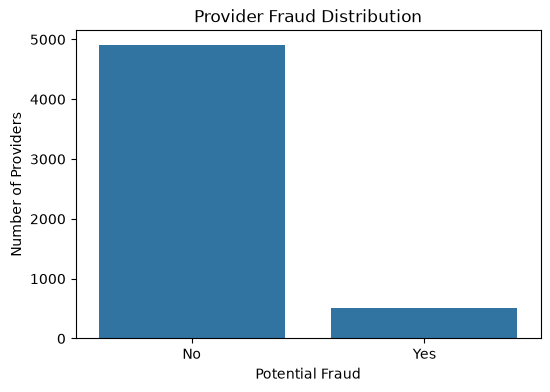

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="PotentialFraud"
)

plt.title("Provider Fraud Distribution")
plt.xlabel("Potential Fraud")
plt.ylabel("Number of Providers")

plt.show()

In [10]:
null_report = pd.DataFrame({
    "Null_Count": df.isna().sum(),
    "Null_Percentage": (
        df.isna().mean() * 100
    )
})

null_report = (
    null_report[
        null_report["Null_Count"] > 0
    ]
    .sort_values(
        "Null_Percentage",
        ascending=False
    )
)

display(null_report)

,Null_Count,Null_Percentage
IP_Unique_Procedure_Codes,3461,63.974122
IP_Avg_Deductible,3327,61.497227
IP_Unique_Beneficiaries,3318,61.330869
IP_Claim_Count,3318,61.330869
IP_Max_Reimbursement,3318,61.330869
IP_Total_Reimbursement,3318,61.330869
IP_Total_Deductible,3318,61.330869
IP_Avg_Claim_Duration,3318,61.330869
IP_Max_Claim_Duration,3318,61.330869
IP_Avg_Reimbursement,3318,61.330869


In [11]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

display(
    df[numeric_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Unique_Beneficiaries,5410.0,67.153420,142.748729,1.000000,8.000000,25.000000,65.000000,2.857000e+03
Avg_Patient_Age,5410.0,74.757406,4.555186,35.331964,72.945393,74.831749,76.612997,1.015825e+02
Avg_Chronic_Conditions,5410.0,4.425597,0.884788,0.000000,4.000000,4.375000,4.800000,1.000000e+01
IP_Claim_Count,2092.0,19.347036,34.983155,1.000000,3.000000,8.000000,19.000000,5.160000e+02
IP_Unique_Beneficiaries,2092.0,17.502868,30.703742,1.000000,3.000000,7.000000,17.000000,4.580000e+02
IP_Total_Reimbursement,2092.0,195170.659656,357963.082369,0.000000,29000.000000,77000.000000,188000.000000,5.580870e+06
IP_Avg_Reimbursement,2092.0,10208.098169,5139.034968,0.000000,7400.000000,9484.693085,11733.962441,5.700000e+04
IP_Max_Reimbursement,2092.0,30028.967495,21317.649565,0.000000,13000.000000,24000.000000,44000.000000,1.250000e+05
IP_Total_Deductible,2092.0,20203.680688,36553.781412,0.000000,3204.000000,8544.000000,19224.000000,5.361360e+05
IP_Avg_Deductible,2083.0,1068.000000,0.000000,1068.000000,1068.000000,1068.000000,1068.000000,1.068000e+03


In [12]:
negative_counts = (
    df[numeric_columns] < 0
).sum()

negative_counts = (
    negative_counts[
        negative_counts > 0
    ]
    .sort_values(ascending=False)
)

display(negative_counts)

Series([], dtype: int64)

In [13]:
X = df.drop(
    columns=[
        "Provider",
        "PotentialFraud"
    ]
).copy()

y = df["PotentialFraud"].map({
    "No": 0,
    "Yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Feature shape: (5410, 30)
Target shape: (5410,)

Target values:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [14]:
print("Missing target values:", y.isna().sum())

print("\nTarget distribution:")
print(y.value_counts())

Missing target values: 0

Target distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [15]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nValidation target:")
print(y_val.value_counts())

Training data: (4328, 30)
Validation data: (1082, 30)

Training target:
PotentialFraud
0    3923
1     405
Name: count, dtype: int64

Validation target:
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [17]:


from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)



In [18]:
# Replace infinite values
X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_val = X_val.replace(
    [np.inf, -np.inf],
    np.nan
)

# Columns where missing means no observed activity
zero_fill_features = [
    col for col in [
        "IP_Claim_Count",
        "IP_Unique_Beneficiaries",
        "IP_Total_Reimbursement",
        "IP_Avg_Reimbursement",
        "IP_Max_Reimbursement",
        "IP_Total_Deductible",
        "IP_Avg_Deductible",
        "IP_Max_Claim_Duration",
        "IP_Avg_Claim_Duration",
        "IP_Unique_Diagnosis_Codes",
        "IP_Unique_Procedure_Codes",
        "OP_Claim_Count",
        "OP_Unique_Beneficiaries",
        "OP_Total_Reimbursement",
        "OP_Avg_Reimbursement",
        "OP_Max_Reimbursement",
        "OP_Total_Deductible",
        "OP_Avg_Deductible"
    ]
    if col in X_train.columns
]

# Fill activity-related missing values
for col in zero_fill_features:
    X_train[col] = X_train[col].fillna(0)
    X_val[col] = X_val[col].fillna(0)

# Remaining missing values → median
remaining = X_train.columns[
    X_train.isna().any()
]

if len(remaining) > 0:
    imputer = SimpleImputer(strategy="median")

    X_train[remaining] = imputer.fit_transform(
        X_train[remaining]
    )

    X_val[remaining] = imputer.transform(
        X_val[remaining]
    )

print(
    "Remaining training nulls:",
    X_train.isna().sum().sum()
)

print(
    "Remaining validation nulls:",
    X_val.isna().sum().sum()
)

Remaining training nulls: 0
Remaining validation nulls: 0


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

log_prob = log_model.predict_proba(
    X_val_scaled
)[:, 1]

log_pred = (
    log_prob >= 0.50
).astype(int)

print(
    classification_report(
        y_val,
        log_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, log_prob), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, log_prob), 4)
)

              precision    recall  f1-score   support

  Legitimate       0.99      0.90      0.94       981
       Fraud       0.49      0.91      0.63       101

    accuracy                           0.90      1082
   macro avg       0.74      0.91      0.79      1082
weighted avg       0.94      0.90      0.91      1082

ROC-AUC: 0.9724
PR-AUC: 0.7975


In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_prob = rf_model.predict_proba(
    X_val
)[:, 1]

rf_pred = (
    rf_prob >= 0.50
).astype(int)

print(
    classification_report(
        y_val,
        rf_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, rf_prob), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, rf_prob), 4)
)

              precision    recall  f1-score   support

  Legitimate       0.98      0.93      0.96       981
       Fraud       0.56      0.83      0.67       101

    accuracy                           0.92      1082
   macro avg       0.77      0.88      0.81      1082
weighted avg       0.94      0.92      0.93      1082

ROC-AUC: 0.9698
PR-AUC: 0.7876


In [21]:
gb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_prob = gb_model.predict_proba(
    X_val
)[:, 1]

gb_pred = (
    gb_prob >= 0.50
).astype(int)

In [22]:
results = []

for name, pred, prob in [
    ("Logistic Regression", log_pred, log_prob),
    ("Random Forest", rf_pred, rf_prob),
    ("Gradient Boosting", gb_pred, gb_prob)
]:

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_val, prob
        ),
        "PR-AUC": average_precision_score(
            y_val, prob
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "PR-AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Gradient Boosting,0.955638,0.819277,0.673267,0.739130,0.970781,0.814234
0,Logistic Regression,0.902033,0.486772,0.910891,0.634483,0.972406,0.797460
1,Random Forest,0.924214,0.563758,0.831683,0.672000,0.969843,0.787596


In [23]:
final_prob = rf_prob
prediction_results = pd.DataFrame({
    "Provider": df.loc[
        X_val.index,
        "Provider"
    ],
    "Fraud_Probability": final_prob
})

prediction_results["Fraud_Percentage"] = (
    prediction_results["Fraud_Probability"] * 100
)

prediction_results["Risk_Level"] = pd.cut(
    prediction_results["Fraud_Probability"],
    bins=[0, 0.30, 0.70, 1.0],
    labels=["LOW", "MEDIUM", "HIGH"],
    include_lowest=True
)

display(
    prediction_results
    .sort_values(
        "Fraud_Probability",
        ascending=False
    )
    .head(20)
)

,Provider,Fraud_Probability,Fraud_Percentage,Risk_Level
2258,PRV53808,0.997380,99.737993,HIGH
3346,PRV55194,0.997365,99.736508,HIGH
3000,PRV54742,0.997168,99.716774,HIGH
2616,PRV54258,0.996129,99.612903,HIGH
1282,PRV52590,0.995334,99.533357,HIGH
305,PRV51390,0.995306,99.530556,HIGH
1596,PRV52985,0.995260,99.525974,HIGH
2250,PRV53797,0.994300,99.429990,HIGH
4446,PRV56560,0.993484,99.348443,HIGH
4334,PRV56416,0.992958,99.295762,HIGH


In [24]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    pred = (
        final_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.20,0.369004,0.990099,0.537634
1,0.25,0.405858,0.960396,0.570588
2,0.30,0.438356,0.950495,0.600000
3,0.35,0.467005,0.910891,0.617450
4,0.40,0.508671,0.871287,0.642336
5,0.45,0.540373,0.861386,0.664122
6,0.50,0.563758,0.831683,0.672000
7,0.55,0.585185,0.782178,0.669492
8,0.60,0.616000,0.762376,0.681416
9,0.65,0.663717,0.742574,0.700935


In [25]:
import pickle
from pathlib import Path

MODEL_PATH = Path.cwd() / "fraud_model_gb.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(gb_model, file)

print("Model saved successfully!")
print("Location:", MODEL_PATH)

Model saved successfully!
Location: c:\Users\DELL\Desktop\CTS_hackathon_demo\models\fraud_model_gb.pkl
